In [13]:
import pandas as pd
import numpy as np
import os
import openpyxl
import matplotlib.pyplot as plt

#### Read lab calibration data

In [14]:
src = r'W:\VUB\_main_research\calibration_TOMST'

df = pd.read_excel(os.path.join(src, 'lab_gravimetric_calibration.xlsx'),
                               sheet_name='data_process',
                              )
df = df.dropna(axis=0, how ='any')

# Convert 'date' and 'time' columns to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.time

# Combine 'date' and 'time' into a single datetime column
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str), errors='coerce')

# Drop the original 'date' and 'time' columns
df = df.drop(columns=['date', 'time'])

#set index to datetime
df.set_index('datetime', inplace=True)

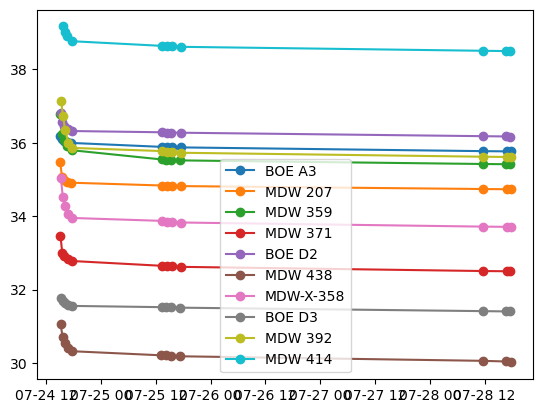

In [24]:
for sample in df['sample'].unique():
    sample_df = df[df['sample'] == sample]
    
    #plot gradient of weight over time
    plt.plot(sample_df['weight_kg'], label=sample, marker='o', linestyle='-')
    plt.legend()